In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
#!wget $data

In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


We need to do some cleaning, make data lower case, replace spaces with '_'

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
strings = list(df.dtypes[df.dtypes == 'str'].index)

In [9]:
df[strings] = df[strings].apply(lambda s: s.str.lower().str.replace(' ','_'))
#for col in strings:
    #df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## **2.3 Exploratory data analysis**

In [11]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

Distribution of price 

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

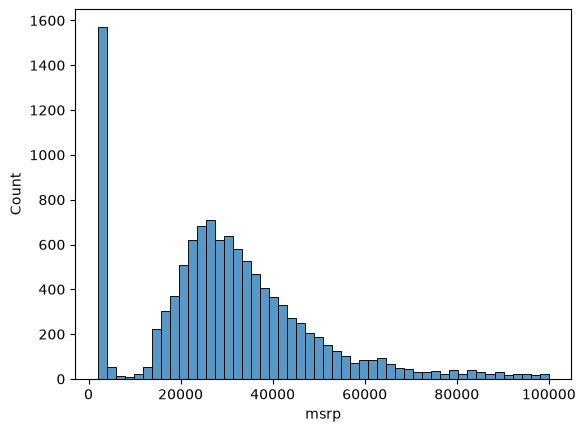

In [13]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

**This kind of distribution is caled Long Tail distribution, this tail will confuse our model, so we want to get rid of this tail, for that we usually apply the logarithmic distribution**

In [14]:
np.log1p([0, 1, 100, 100000])
# np.log1p() helps us to prevent the error because of values equal to zero 

array([ 0.        ,  0.69314718,  4.61512052, 11.51293546])

In [15]:
price_logs = np.log1p(df.msrp)

In [16]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

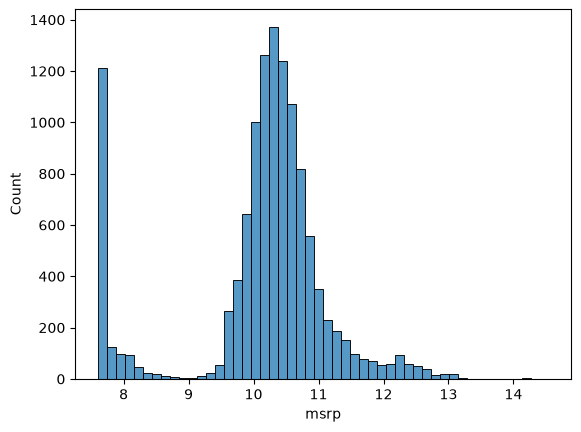

In [17]:
sns.histplot(price_logs, bins=50)

**We get almost a Normal Distribution**

In [18]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## **2.4 Setting up the validation framework**

In [19]:
n = len(df)
n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = n - n_test - n_val

In [20]:
idx = np.arange(n)

In [21]:
np.random.seed(2)
np.random.shuffle(idx)

In [22]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [23]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [24]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [25]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [26]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)
#(.values) we use to rid the indexes and transfer from pandas series to numpy array 

In [27]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']
#delete the data to prevent accidentally using of it 

In [28]:
len(y_train)
y_train 

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

## **2.5 Linear Regression**

In [29]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [30]:
xi = [453, 11, 86]

In [31]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [32]:
def linear_regression(xi):
    y = w0
    for i in range(len(w)):
        y += w[i]*xi[i]
    return y

In [33]:
linear_regression(xi)

12.312

In [34]:
np.expm1(12.312)
#expm1 exponent that subtract1, we added before logarithm, so we need to subtract it

np.float64(222347.2221101062)

## **2.6 Linear Regression vector form**

In [35]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]
    return res

In [36]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [37]:
w_new = [w0] + w

In [38]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [39]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [40]:
linear_regression(xi)

12.312

**We just rid of w0 term, adding it to a vector of weights, and adding 1 to features vector, result is the same, but form is shorter**

In [41]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [42]:
def linear_regression_X(X):
    return X.dot(w_new)

In [43]:
linear_regression_X(X)

array([12.38 , 13.552, 12.312])

## **2.7 Training a linear regression model**

$$X * w = y$$  
$$ X^{-1} * X = 1$$  
**Matrix multiplied by its inverse matrix will be equal 1**
$$w = X^{-1} *  y$$  
**But inverse matrix exists only for square matrixes**
$$X^T * X$$ **Gram Matrix has square form, but inverse matrix exsists not always**
$$X^T * X * w = X^T * y$$
$$(X^T * X)^{-1} * (X^T * X) * w = (X^T * X)^{-1} * X^T * y$$
$$w = (X^T * X)^{-1} * X^T * y$$

In [44]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    w0 = w[0]
    w = w[1:]
    return w0, w
train_linear_regression(X, y)

(np.float64(300.06776692555627),
 array([-0.22774253, -2.5769413 , -0.02301206]))

## **2.8 Car price baseline model**

In [45]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [46]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [47]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [48]:
df_train[base].fillna(0)

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [49]:
X_train = df_train[base].fillna(0).values

In [50]:
w0, w = train_linear_regression(X_train, y_train)

In [51]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

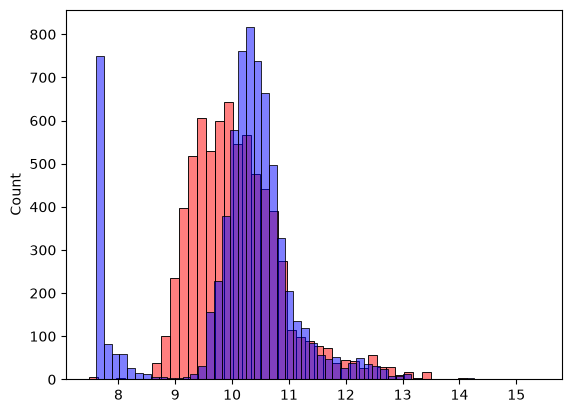

In [52]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
#alpha=0.5 - transparency of the color 
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## **2.9 RMSE**

In [53]:
def rmse(y_pred, y):
    err = (y_pred - y) ** 2 
    mse = np.mean(err)
    return np.sqrt(mse)

In [54]:
rmse(y_pred, y_train)

np.float64(0.7554192603920132)

## **2.10 Validating the model**

In [55]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [56]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.7616530991301627)

## **2.11 Simple feature engineering**

In [57]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [58]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [59]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.5172055461058327)

<Axes: ylabel='Count'>

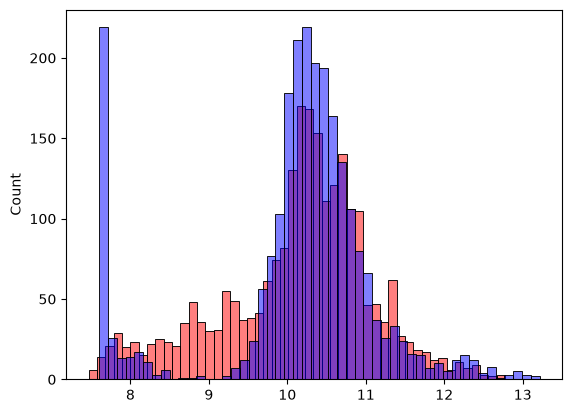

In [60]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
#alpha=0.5 - transparency of the color 
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

## **2.12 Categorical variables**

In [67]:
(df_train.number_of_doors == 2).astype('int')
(df_train.number_of_doors == 3).astype('int')
(df_train.number_of_doors == 4).astype('int')

0       0
1       1
2       1
3       0
4       1
       ..
7145    0
7146    0
7147    1
7148    1
7149    1
Name: number_of_doors, Length: 7150, dtype: int64

In [90]:
for v in np.sort(df_train.number_of_doors.dropna().unique().astype('int')):
    df_train['num_doors_%s' %  v] = (df_train.number_of_doors == v).astype('int')

In [91]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,1,0,0
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,1,0,0
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,0,0,1
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,0,0,1


In [92]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year 
    features.append('age')

    for v in np.sort(df.number_of_doors.dropna().unique().astype('int')):
        df['num_doors_%s' %  v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %  v)
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [94]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.5157995641501902)

In [114]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [99]:
df[df.make == 'bugatti']

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11362,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,2065902
11363,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1500000
11364,bugatti,veyron_16.4,2009,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1705769


In [113]:
df.market_category.value_counts().head()

market_category
crossover             1110
flex_fuel              872
luxury                 855
luxury,performance     673
hatchback              641
Name: count, dtype: int64

In [125]:
def prepare_X(df, doors=None, cats=None):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    if doors is None:
        doors = np.sort(df.number_of_doors.dropna().unique().astype('int'))
    for v in doors:
        df[f'num_doors_{v}'] = (df.number_of_doors == v).astype('int')
        features.append(f'num_doors_{v}')

    if cats is None:
        cats = sorted(df.market_category.dropna().unique())
    for cat in cats:
        df[f'{cat}'] = (df.market_category == cat).astype('int')
        features.append(f'{cat}')

    X = df[features].fillna(0).values
    return X, doors, cats

X_train, doors, cats = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val, _, _ = prepare_X(df_val, doors, cats)
y_pred = w0 + X_val.dot(w)
rmse(y_pred, y_val)

np.float64(0.46440614878854297)

In [157]:
mask = df_val["market_category"].notna().values
df_val_copy = df_val[mask]
y_val_copy = y_val[mask]
mask

array([False,  True,  True, ...,  True, False,  True], shape=(2382,))

In [158]:
df_val_copy

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204
6,nissan,murano,2016,regular_unleaded,260.0,6.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,28,21,2009
7,saab,900,1996,regular_unleaded,185.0,4.0,manual,front_wheel_drive,2.0,"luxury,performance",compact,convertible,26,18,376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,volvo,xc90,2017,premium_unleaded_(recommended),316.0,4.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",large,4dr_suv,25,20,870
2377,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
2378,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
2379,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624


In [159]:
y_val_copy

array([10.90872279,  9.72770457, 10.65963301, ..., 11.88958635,
       11.21756062, 10.1924563 ], shape=(1621,))

In [165]:
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [167]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year 
    features.append('age')

    for v in np.sort(df.number_of_doors.dropna().unique().astype('int')):
        df['num_doors_%s' %  v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %  v)

    for m in list(df.make.value_counts().head().index):
        df['make_%s' %  m] = (df.make == m).astype('int')
        features.append('make_%s' %  m)
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [168]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.5076038849556633)

In [239]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
 'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [248]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year 
    features.append('age')

    for v in np.sort(df.number_of_doors.dropna().unique().astype('int')):
        df['num_doors_%s' %  v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %  v)

    for cat, val in categories.items():
        for v in val:
            df[f'{cat}_{v}'] = (df[cat] == v).astype('int')
            features.append(f'{cat}_{v}')

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [249]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(28.478764165331985)

## **2.13 Regularization**

In [250]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [251]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [252]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(113.55512071962342)

In [253]:
w0, w

(np.float64(-292975507188272.25),
 array([-1.94204667e-02, -8.44049639e+00,  4.18197946e-01, -7.24923387e-01,
        -1.43876150e-03, -7.43833334e-01,  8.71810032e+02,  8.46669570e+02,
         8.58349986e+02, -4.42390313e+00,  3.41491294e+00, -3.16297901e+00,
         8.58984632e+00, -1.15071526e+01, -1.96686350e+00, -1.07272250e+01,
        -4.82722874e+00, -2.93588658e+01, -6.00895660e+01, -9.18904890e+01,
        -8.66432254e+01, -9.59117190e+01, -8.73772648e+01, -9.92397920e+01,
         2.92975507e+14,  2.92975507e+14,  2.92975507e+14,  2.92975507e+14,
         2.47790122e+00,  1.90357987e+00, -4.57116994e+00, -4.32985422e-01,
        -2.87067662e+00, -2.92281644e+01, -3.80682704e+01, -3.58223622e+01,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

In [265]:
def train_linear_regression_reg(X, y, r=0.001):
    
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    w0 = w[0]
    w = w[1:]
    return w0, w

In [266]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4608158583830182)

## **2.14 Tuning the model**

In [267]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 -292975507188272.25 113.55512071962342
1e-05 7.877078971380707 0.4608153161997021
0.0001 7.135017378207604 0.46081536448154503
0.001 7.131037736232789 0.4608158583830182
0.1 7.000232407249966 0.4608736549126053
1 6.250747847380808 0.46158128382721536
10 4.729512585714188 0.47260987726669534


## **2.15 Using the model**

In [272]:
df_full_train = pd.concat([df_train, df_val])

In [274]:
df_full_train = df_full_train.reset_index(drop=True)

In [275]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [276]:
X_full_train = prepare_X(df_full_train)

In [277]:
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [280]:
y_full_train = np.concatenate([y_train, y_val])

In [281]:
 w0, w = train_linear_regression_reg(X_full_train, y_full_train, r = 0.001)

In [282]:
 w0, w

(np.float64(7.175122906174352),
 array([ 1.80193323e-03,  1.26575150e-01, -6.78607869e-03,  7.75903944e-03,
        -5.33226045e-05, -9.73063833e-02, -1.27241551e+00, -1.30599119e+00,
        -9.95968845e-01, -6.27479237e-02,  1.82139249e-01,  2.83073943e-02,
         1.29063899e-02, -1.32624473e-01, -2.69110366e-01, -6.50985209e-01,
        -3.21721815e-01, -3.55424918e-01, -3.51216100e-01, -6.61059030e-01,
        -1.19526928e-01, -5.15904828e-01, -6.99730869e-01, -3.25276693e-01,
         1.80653994e+00,  1.75085365e+00,  1.82842615e+00,  1.79029461e+00,
        -5.47616421e-02,  1.19033259e-01, -2.65289015e-02,  7.42029339e-03,
        -7.49067027e-03,  2.42691857e+00,  2.35931703e+00,  2.38908624e+00,
        -1.47584145e-01, -2.46551739e-02,  1.81542645e-01,  3.55084073e-01,
        -2.79089708e-01]))

In [285]:
X_test = prepare_X(df_test)

y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

In [286]:
score

np.float64(0.46007539707417416)

## **2.16 Next steps**
- We included only 5 top features. What happens if we include 10?
   
Other projects  

- Predict the price of a house - e.g. boston dataset
- https://archive.ics.uci.edu/ml/datasets.php?task=reg
- https://archive.ics.uci.edu/ml/datasets/Student+Performance

## **2.17 Summary**
- EDA - looking at data, finding missing values
- Target variable distribution - long tail => bell shaped curve
- Validation framework: train/val/test split (helped us detect problems)
- Normal equation - not magic, but math
- Implemented it with numpy
- RMSE to validate our model
- Feature engineering: age, categorical features
- Regularization to fight numerical instability